In [2]:
!pip install -q "trl==1.4.0" peft bitsandbytes accelerate datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 751.0/751.0 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 17.8 MB/s eta 0:00:00


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import torch, os, gc
import numpy as np, pandas as pd
from transformers import (AutoModelForCausalLM, AutoTokenizer,
                          BitsAndBytesConfig, EarlyStoppingCallback)
from peft import (LoraConfig, get_peft_model,
                  prepare_model_for_kbit_training, TaskType)
from trl import SFTTrainer, SFTConfig
from datasets import Dataset

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

# >>> Sadece bu 3 satır modele özel — Gemma için de bunları değiştir <
MODEL_ID   = "Qwen/Qwen2.5-1.5B-Instruct"
MODEL_KEY  = "qwen25"
MODEL_NAME = "Qwen2.5-1.5B-Instruct"

OUTPUT_DIR = f"/content/drive/MyDrive/bdm_proje/models/{MODEL_KEY}_qlora"
os.makedirs(OUTPUT_DIR, exist_ok=True)
LABEL_NAMES = {0:"Yardım Talebi",1:"Kayıp Bildirimi",2:"Altyapı Hasarı",
               3:"Bağış/Koordinasyon",4:"Diğer/İlgisiz"}

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

def make_instruction(tweet):
    return ("Sen bir deprem acil durum sınıflandırma asistanısın. "
            "Verilen tweeti aşağıdaki kategorilerden birine koy. "
            "SADECE kategori adını yaz, başka hiçbir şey yazma.\n\n"
            f"Tweet: {tweet}\n\n"
            "Kategoriler:\n- Yardım Talebi\n- Kayıp Bildirimi\n- Altyapı Hasarı\n"
            "- Bağış/Koordinasyon\n- Diğer/İlgisiz")

def to_pc(df):
    rows = []
    for _, r in df.iterrows():
        msgs = [{"role":"user","content":make_instruction(r['tweet'])}]
        prompt = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        rows.append({"prompt": prompt, "completion": LABEL_NAMES[int(r['label_id'])]})
    return Dataset.from_list(rows)

train_df = pd.read_csv('/content/drive/MyDrive/bdm_proje/data/processed/train.csv')
val_df   = pd.read_csv('/content/drive/MyDrive/bdm_proje/data/processed/val.csv')
train_dataset = to_pc(train_df); val_dataset = to_pc(val_df)
print("Örnek prompt:\n", train_dataset[0]['prompt'][:300], "\n→", train_dataset[0]['completion'])

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True,
)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, quantization_config=bnb_config, device_map="auto", dtype=torch.bfloat16,
)
model.config.use_cache = False
model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)
model = get_peft_model(model, LoraConfig(
    r=16, lora_alpha=32, target_modules=["q_proj","v_proj","k_proj","o_proj"],
    lora_dropout=0.05, bias="none", task_type=TaskType.CAUSAL_LM,
))
model.print_trainable_parameters()

sft_config = SFTConfig(
    output_dir=OUTPUT_DIR, num_train_epochs=3,
    per_device_train_batch_size=4, per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-4, weight_decay=0.01, warmup_ratio=0.03, lr_scheduler_type="cosine",
    eval_strategy="steps", eval_steps=50, save_strategy="steps", save_steps=50,
    save_total_limit=2, load_best_model_at_end=True, metric_for_best_model="eval_loss",
    logging_steps=10, report_to="none", completion_only_loss=True, seed=SEED,
    fp16=False, bf16=True,
)
trainer = SFTTrainer(model=model, train_dataset=train_dataset, eval_dataset=val_dataset,
    args=sft_config, processing_class=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)])

torch.cuda.reset_peak_memory_stats()
print("Eğitim başlıyor...\n")
train_result = trainer.train()
train_runtime_s = train_result.metrics['train_runtime']
gpu_mem_gb = torch.cuda.max_memory_allocated() / 1e9
print(f"\n✅ Tamamlandı! Loss={train_result.training_loss:.4f} | "
      f"Süre={train_runtime_s:.0f}s | Peak GPU={gpu_mem_gb:.2f}GB")
trainer.save_model(OUTPUT_DIR); tokenizer.save_pretrained(OUTPUT_DIR)
print(f"✅ Adaptör kaydedildi: {OUTPUT_DIR}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Tokenizing eval dataset:   0%|          | 0/80 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Eğitim başlıyor...



Step,Training Loss,Validation Loss
50,0.022134,0.069078
100,0.009231,0.016845



✅ Tamamlandı! Loss=0.0601 | Süre=2151s | Peak GPU=5.07GB
✅ Adaptör kaydedildi: /content/drive/MyDrive/bdm_proje/models/qwen25_qlora


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Qwen2.5-1.5B-Instruct — QLoRA FINE-TUNED SONUÇLARI
Accuracy    : 0.9250  (92.5%)
Macro-F1    : 0.9139
Weighted-F1 : 0.9252
Inference   : 1120.4 ms/tweet
Parse fail  : 0/80

                    precision    recall  f1-score   support

     Yardım Talebi       0.91      1.00      0.95        29
   Kayıp Bildirimi       1.00      0.80      0.89        10
    Altyapı Hasarı       1.00      1.00      1.00        10
Bağış/Koordinasyon       0.75      0.82      0.78        11
     Diğer/İlgisiz       1.00      0.90      0.95        20

          accuracy                           0.93        80
         macro avg       0.93      0.90      0.91        80
      weighted avg       0.93      0.93      0.93        80



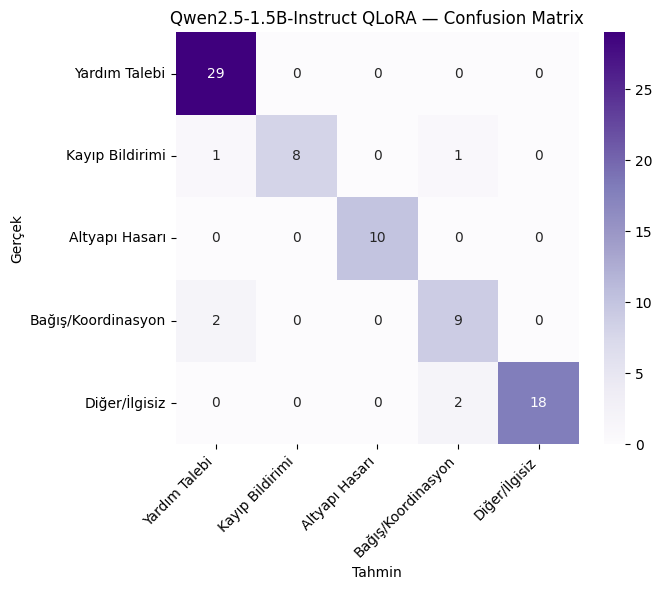


✅ Kaydedildi → /content/drive/MyDrive/bdm_proje/results/fine_tuned (qwen25_qlora_*)


In [7]:
import torch, time, json, os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

test_df = pd.read_csv('/content/drive/MyDrive/bdm_proje/data/processed/test.csv')
model.config.use_cache = True; model.eval()

def parse_label(text):
    t = text.lower()
    if "yardım" in t or "yardim" in t:                      return 0
    if "kayıp" in t or "kayip" in t:                        return 1
    if "altyapı" in t or "altyapi" in t:                    return 2
    if "bağış" in t or "bagis" in t or "koordinasyon" in t: return 3
    if "diğer" in t or "diger" in t or "ilgisiz" in t:      return 4
    return -1

preds, trues, lat, rows = [], [], [], []
for _, row in test_df.iterrows():
    msgs = [{"role":"user","content":make_instruction(row['tweet'])}]
    prompt = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inp = tokenizer(prompt, return_tensors="pt").to(model.device)
    n = inp['input_ids'].shape[1]
    t0 = time.time()
    with torch.no_grad():
        out = model.generate(**inp, max_new_tokens=12, do_sample=False,
                             pad_token_id=tokenizer.pad_token_id)
    lat.append((time.time()-t0)*1000)
    gen = tokenizer.decode(out[0][n:], skip_special_tokens=True).strip()
    pid = parse_label(gen); pred = pid if pid!=-1 else 4
    g = int(row['label_id']); preds.append(pred); trues.append(g)
    rows.append({'tweet':row['tweet'],'gercek':g,'gercek_ad':LABEL_NAMES[g],
                 'model_yanit':gen,'tahmin':pred,'tahmin_ad':LABEL_NAMES[pred],
                 'parse_fail':pid==-1,'dogru_mu':pred==g})

acc = accuracy_score(trues, preds)
mf1 = f1_score(trues, preds, average='macro', zero_division=0)
wf1 = f1_score(trues, preds, average='weighted', zero_division=0)
print("="*55); print(f"{MODEL_NAME} — QLoRA FINE-TUNED SONUÇLARI"); print("="*55)
print(f"Accuracy    : {acc:.4f}  ({acc*100:.1f}%)")
print(f"Macro-F1    : {mf1:.4f}\nWeighted-F1 : {wf1:.4f}")
print(f"Inference   : {np.mean(lat):.1f} ms/tweet")
print(f"Parse fail  : {sum(r['parse_fail'] for r in rows)}/{len(rows)}\n")
print(classification_report(trues, preds, labels=[0,1,2,3,4],
      target_names=[LABEL_NAMES[i] for i in range(5)], zero_division=0))
cm = confusion_matrix(trues, preds, labels=[0,1,2,3,4])

out_dir = '/content/drive/MyDrive/bdm_proje/results/fine_tuned'; os.makedirs(out_dir, exist_ok=True)
sonuc = {"model":MODEL_NAME,"yontem":"QLoRA (4-bit NF4, bf16)","seed":SEED,
    "test_size":int(len(test_df)),"accuracy":round(float(acc),4),"f1_macro":round(float(mf1),4),
    "f1_weighted":round(float(wf1),4),"inference_ms":round(float(np.mean(lat)),1),
    "egitim_suresi_s":round(float(train_runtime_s),0),"peak_gpu_gb":round(float(gpu_mem_gb),2),
    "egitilen_param":int(sum(p.numel() for p in model.parameters() if p.requires_grad)),
    "parse_basarisiz":int(sum(r['parse_fail'] for r in rows)),"confusion_matrix":cm.tolist(),
    "classification_report":classification_report(trues,preds,labels=[0,1,2,3,4],
        target_names=[LABEL_NAMES[i] for i in range(5)],zero_division=0,output_dict=True)}
with open(os.path.join(out_dir,f'{MODEL_KEY}_qlora_sonuc.json'),'w',encoding='utf-8') as f:
    json.dump(sonuc, f, ensure_ascii=False, indent=2)
pd.DataFrame(rows).query('dogru_mu == False').to_csv(
    os.path.join(out_dir,f'{MODEL_KEY}_qlora_hatalar.csv'), index=False, encoding='utf-8')
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=[LABEL_NAMES[i] for i in range(5)],
            yticklabels=[LABEL_NAMES[i] for i in range(5)])
plt.xlabel('Tahmin'); plt.ylabel('Gerçek'); plt.title(f'{MODEL_NAME} QLoRA — Confusion Matrix')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0); plt.tight_layout()
plt.savefig(os.path.join(out_dir,f'{MODEL_KEY}_qlora_cm.png'), dpi=150, bbox_inches='tight'); plt.show()
print(f"\n✅ Kaydedildi → {out_dir} ({MODEL_KEY}_qlora_*)")

After mounting your Google Drive, you'll need to specify the correct path to your `data.csv` file. You can typically find it under `/content/drive/MyDrive/` followed by the folder structure where you saved it. For example, if it's directly in your 'MyDrive', the path would be `'/content/drive/MyDrive/data.csv'`.